# Moving to Nonlinear Models

Last semester, you primarily worked with linear models, where the question of "what can we do with linear combinations of our features" is the core idea.  Of course, if the vector space defined by your features isn’t useful, the answer is, “not very much.” This can seem extremely limiting. For example, consider the following classification problem, where we'd like to classify red points from blue points:

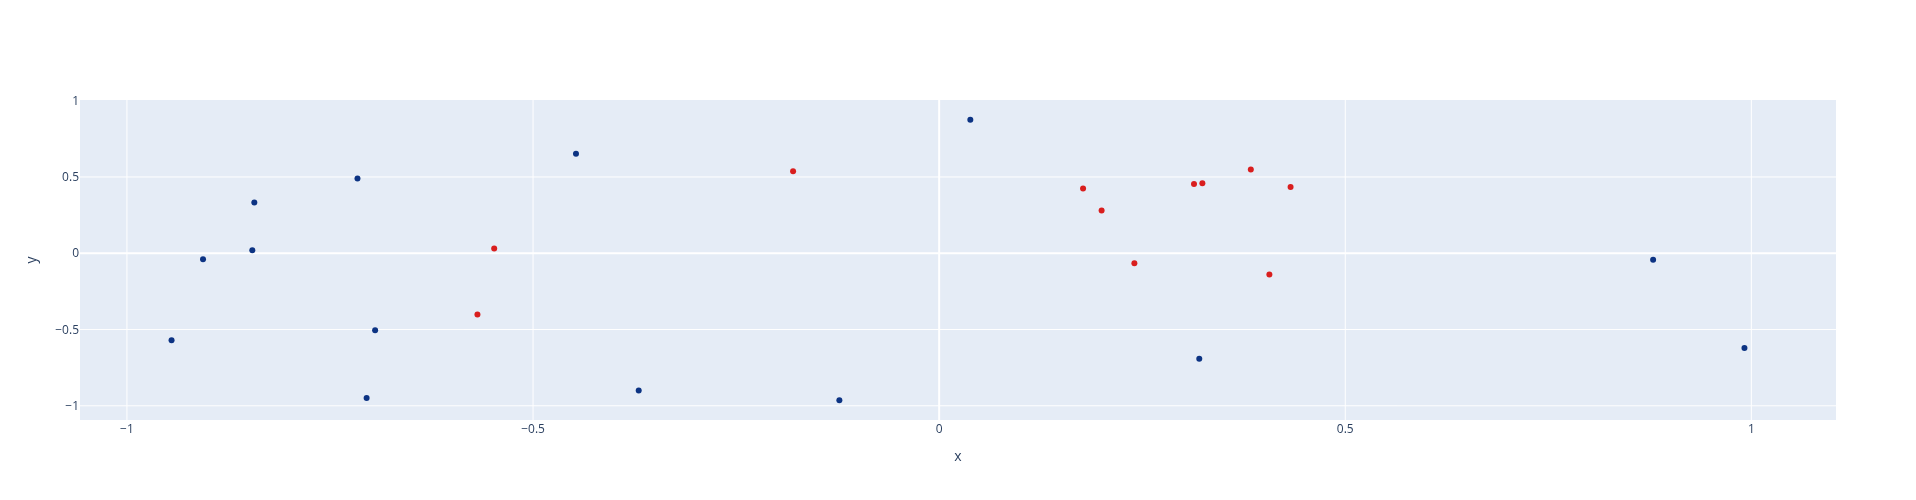

In [1]:
import numpy as np
loaded=np.load('nonseparable.npz')
X=loaded['array1']
y=loaded['array2']
import plotly.graph_objects as go
fig=go.Figure(data=go.Scatter(x=X[:,0],y=X[:,1],mode='markers',
                              marker=dict(color=y,colorscale='Portland')))
fig.update_layout(height=500,width=500,xaxis_title='x',yaxis_title='y')
fig.show()

In this picture, we have two features, labeled $x$ and $y$.  If we want to do our classification with logistic regression, for example, using the notation from your book last semester, we would need to find the values $\beta_i$ such that the logit $\beta_0+\beta_1 x +\beta_2 y$ allows us to calculate the probability that a point is red.  Because the logit is a linear function on the features given, the point where the probability is .5, or the "decision boundary," will be a line; our linear classifier says everything on one side of that line is probably a red dot, and everything on the other side of that line is a blue dot. (If this doesn't sound familiar, you can read about it again in chapter 4.3 of [the ISL book](https://www.usna.edu/Users/cs/SD312/resources/ISL.pdf)).

**As a minor parenthetical notation note** - statisticians tend to like the notation from your ISL book. I, and many ML people, tend to prefer a more linear algebraic notation. Here, I can organize the linear combination like so:

$$
\begin{bmatrix} x & y & 1 \end{bmatrix} \begin{bmatrix} \beta_1 \\ \beta_2 \\ \beta_0 \end{bmatrix},
$$

then allowing us to organize all datapoints into a single matrix, giving us a single multiplication that gives us the logits of all datapoints:

$$
\begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ \vdots & \vdots & \vdots \end{bmatrix} \begin{bmatrix} \beta_1 \\ \beta_2 \\ \beta_0 \end{bmatrix}.
$$
Also, I tend to use $w$, not $\beta$, to refer to that vector of weights.  **End of parenthetical aside**

OK, fine.  So we have a matrix $X$ and labels $y$, and we feed it into sklearn's logistic regression, and it does its best:

In [2]:
import sklearn.linear_model
LR=sklearn.linear_model.LogisticRegression()
LR.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

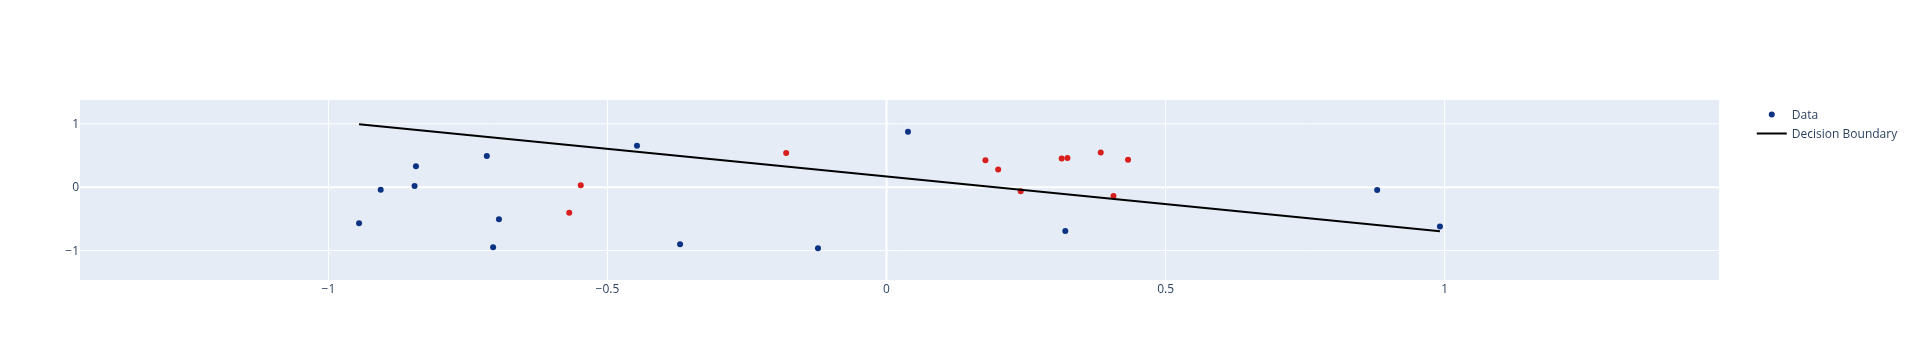

In [3]:
import numpy as np
import plotly.graph_objects as go

# 1. Extract model parameters
# LR.coef_ returns shape (1, n_features), LR.intercept_ returns shape (1,)
w = LR.coef_[0]
b = LR.intercept_[0]

# 2. Calculate the line coordinates
# Create a range of x values spanning the data
x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

# Calculate corresponding y values using the derived equation
y_line = -(w[0] * x_line + b) / w[1]

# 3. Create the figure
fig = go.Figure()

# Add the data points
fig.add_trace(go.Scatter(
    x=X[:, 0], 
    y=X[:, 1], 
    mode='markers',
    name='Data',
    marker=dict(color=y, colorscale='Portland')
))

# Add the decision boundary line
fig.add_trace(go.Scatter(
    x=x_line, 
    y=y_line, 
    mode='lines',
    name='Decision Boundary',
    line=dict(color='black', width=2)
))

# Optional: Set axis limits to match data range so the line doesn't zoom out the plot
fig.update_layout(
    xaxis_range=[X[:, 0].min() - 0.5, X[:, 0].max() + 0.5],
    yaxis_range=[X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]
)

fig.show()

Its best is not good!  That's a bad decision boundary!  But, given the constraint that the decision boundary has to be a line, it really doesn't have a choice.  The assignment you gave it was impossible.  So, it seems that linear models are a waste of time that don't work on real data.

Of course, if that were the case, we wouldn't have asked you to spend a semester on linear models. 

A very, very, very important idea is that in linear models, you are limited to linear combinations of features, but you can use literally any features you want! This basic idea makes linear models very powerful. For example, for this data, suppose rather than using the features $[x, y, 1]$, we instead used the features $[x^2, y^2, 1]$? That is, suppose we had a dot at $[−1, .5]$. Well, rather than having its row in the matrix represented with those two numbers, I’ll instead use $[ −1^2, .5^2]$, or $[1, 0.25]$. If I do this for all points in this set, and plot it on this new $x^2, y^2$ axes, this is what I get:

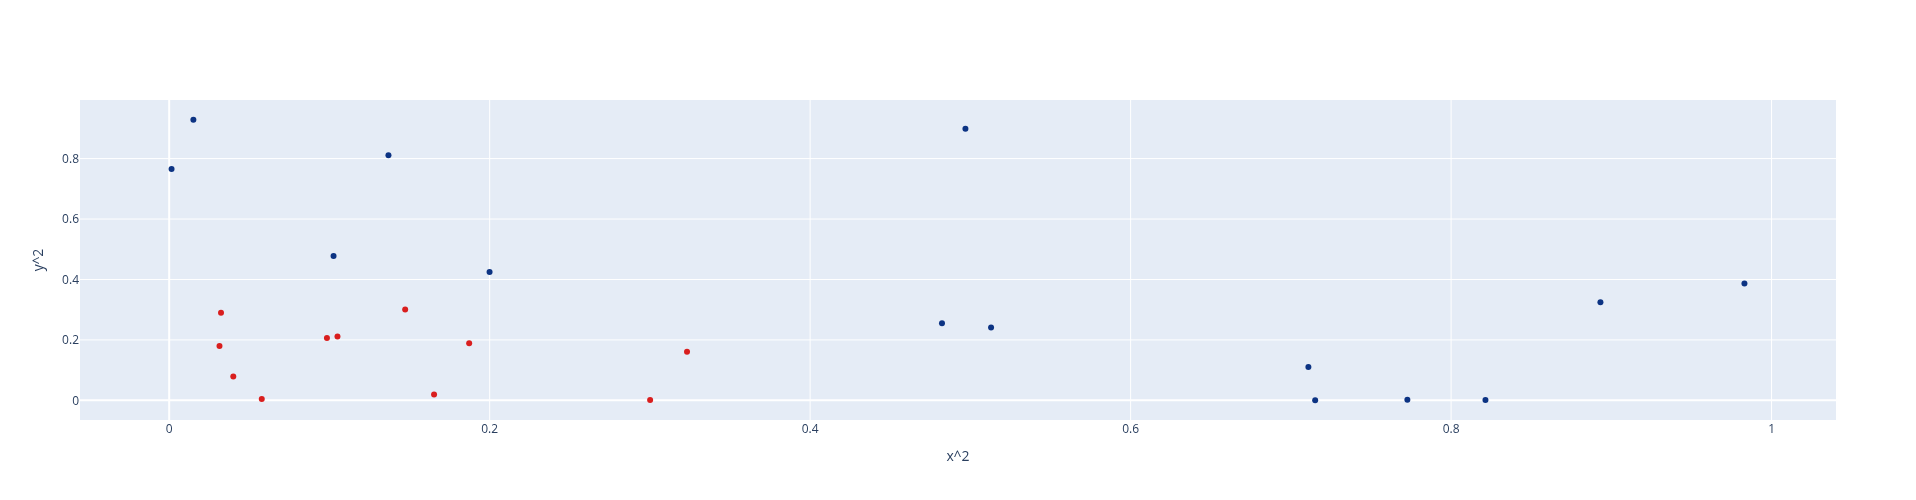

In [4]:
n=X.shape[0]
newX=np.ones((n,2))
newX[:,0]=X[:,0]*X[:,0]
newX[:,1]=X[:,1]*X[:,1]
fig=go.Figure(data=go.Scatter(x=newX[:,0],y=newX[:,1],mode='markers',
                              marker=dict(color=y,colorscale='Portland')))
fig.update_layout(height=500,width=500,xaxis_title='x^2',yaxis_title='y^2')
fig.show()

That data is entirely separable, and we can build a dependable classifier easily:

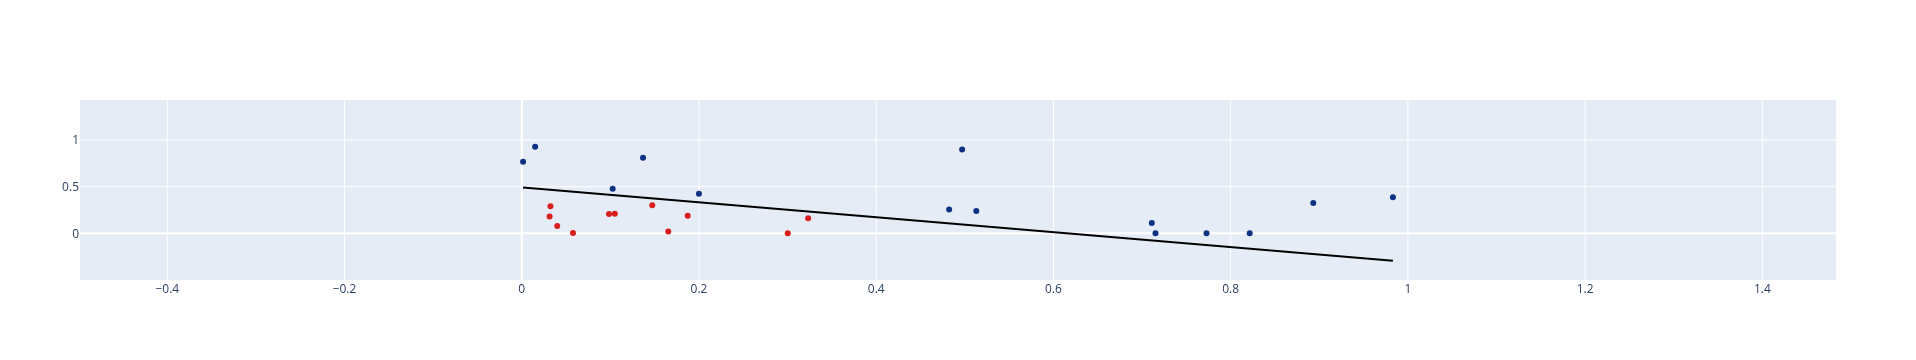

In [5]:
newLR=sklearn.linear_model.LogisticRegression(C=1e5)
newLR.fit(newX,y)
# 1. Extract model parameters
# LR.coef_ returns shape (1, n_features), LR.intercept_ returns shape (1,)
w = newLR.coef_[0]
b = newLR.intercept_[0]

# 2. Calculate the line coordinates
# Create a range of x values spanning the data
x_line = np.linspace(newX[:, 0].min(), newX[:, 0].max(), 100)

# Calculate corresponding y values using the derived equation
y_line = -(w[0] * x_line + b) / w[1]

# 3. Create the figure
fig = go.Figure()

# Add the data points
fig.add_trace(go.Scatter(
    x=newX[:, 0], 
    y=newX[:, 1], 
    mode='markers',
    marker=dict(color=y, colorscale='Portland')
))

# Add the decision boundary line
fig.add_trace(go.Scatter(
    x=x_line, 
    y=y_line, 
    mode='lines',
    name='Decision Boundary',
    line=dict(color='black', width=2)
))

# Optional: Set axis limits to match data range so the line doesn't zoom out the plot
fig.update_layout(
    showlegend=False,
    xaxis_range=[newX[:, 0].min() - 0.5, newX[:, 0].max() + 0.5],
    yaxis_range=[newX[:, 1].min() - 0.5, newX[:, 1].max() + 0.5]
)

fig.show()

he line in this image is the *decision boundary*, such that things on one side are in the black set, and things on the other are in the yellow set.  Of course, it's linear.  If we were to move every point on that line back to the original data set, though, it wouldn't be.  By that, I mean that every point on that line in $(x^2,y^2)$ space, maps to (actually 4) points in the original space: $(\sqrt{x^2},\sqrt{y^2}),(-\sqrt{x^2},\sqrt{y^2}),(\sqrt{x^2},-\sqrt{y^2}),(-\sqrt{x^2},-\sqrt{y^2})$.  That looks like this:

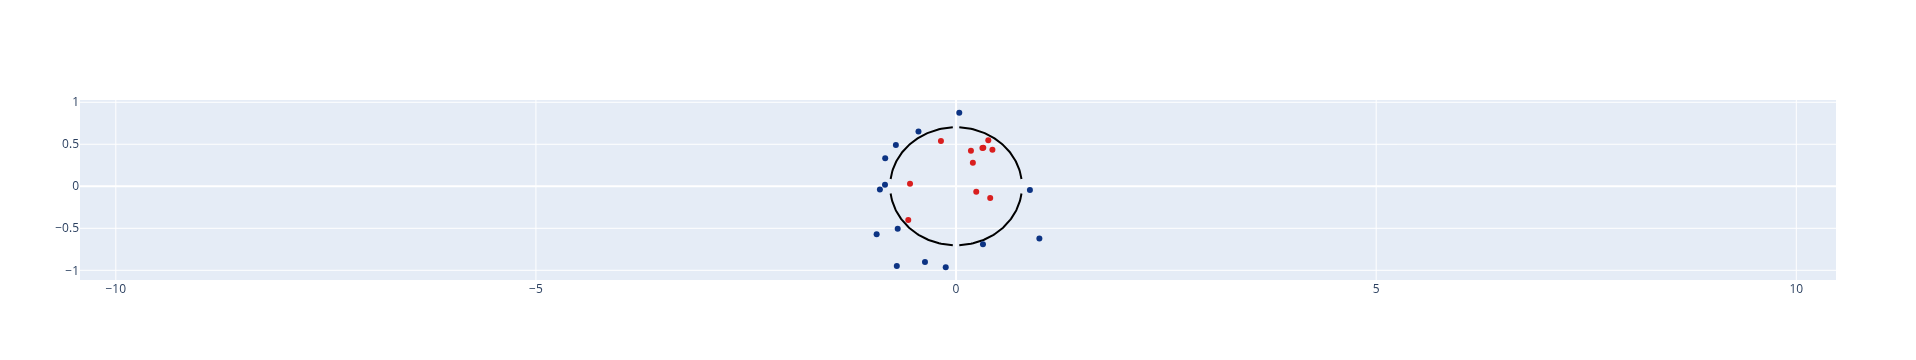

In [8]:
import numpy as np
import plotly.graph_objects as go

# 1. Filter for valid points in the squared space
# The line is in x^2, y^2 space, so values must be >= 0 to map back to real x, y
valid_mask = (x_line >= 0) & (y_line >= 0)
x_sq_valid = x_line[valid_mask]
y_sq_valid = y_line[valid_mask]

# 2. Transform back to linear space (take square roots)
x_root = np.sqrt(x_sq_valid)
y_root = np.sqrt(y_sq_valid)

# 3. Create the 4 quadrants of the circle/ellipse
# Quadrant 1: (+x, +y)
q1_x, q1_y = x_root, y_root
# Quadrant 2: (-x, +y)
q2_x, q2_y = -x_root, y_root
# Quadrant 3: (-x, -y)
q3_x, q3_y = -x_root, -y_root
# Quadrant 4: (+x, -y)
q4_x, q4_y = x_root, -y_root

# 4. Plot the resulting shape
fig = go.Figure()

# Helper to add trace efficiently
def add_quadrant(fig, x, y, name):
    fig.add_trace(go.Scatter(
        x=x, y=y, 
        mode='lines', 
        line=dict(color='black', width=2),
        showlegend=False,
        name=name
    ))

add_quadrant(fig, q1_x, q1_y, "Q1")
add_quadrant(fig, q2_x, q2_y, "Q2")
add_quadrant(fig, q3_x, q3_y, "Q3")
add_quadrant(fig, q4_x, q4_y, "Q4")

fig.add_trace(go.Scatter(
    x=X[:, 0], 
    y=X[:, 1], 
    mode='markers',
    marker=dict(color=y, colorscale='Portland')
))

# Set aspect ratio to 1 so the circle doesn't look like an oval due to scaling
fig.update_layout(
    yaxis=dict(scaleanchor="x", scaleratio=1),
    showlegend=False
)

fig.show()

So, it's still a linear classifier, but not in the original space. We've used a linear classifier to make a non-linear decision boundary. And that's OK! and normal! and powerful!